In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/projects/Medical/kaggledata'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)


In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth


=== DDPM Training Start ===
Device: cuda
Total epochs: 50
Batch size: 32
Total batches per epoch: 6189


Epoch 1/50: 100%|██████████| 6189/6189 [01:31<00:00, 67.47it/s, loss=0.0653]


Epoch 1/50 - Avg Loss: 0.1016


Epoch 2/50: 100%|██████████| 6189/6189 [01:30<00:00, 68.44it/s, loss=0.0393]


Epoch 2/50 - Avg Loss: 0.0607


...

Epoch 48/50 - Avg Loss: 0.0446


Epoch 49/50: 100%|██████████| 6189/6189 [01:32<00:00, 66.84it/s, loss=0.0274]


Epoch 49/50 - Avg Loss: 0.0442


Epoch 50/50: 100%|██████████| 6189/6189 [01:33<00:00, 65.89it/s, loss=0.0222]


Epoch 50/50 - Avg Loss: 0.0446
  → Saved checkpoint: ddpm_checkpoints/ddpm_pcam_epoch50.pth
  → Generating samples...
  → Saved samples: ddpm_samples/samples_epoch50.png

=== 学習完了! ===


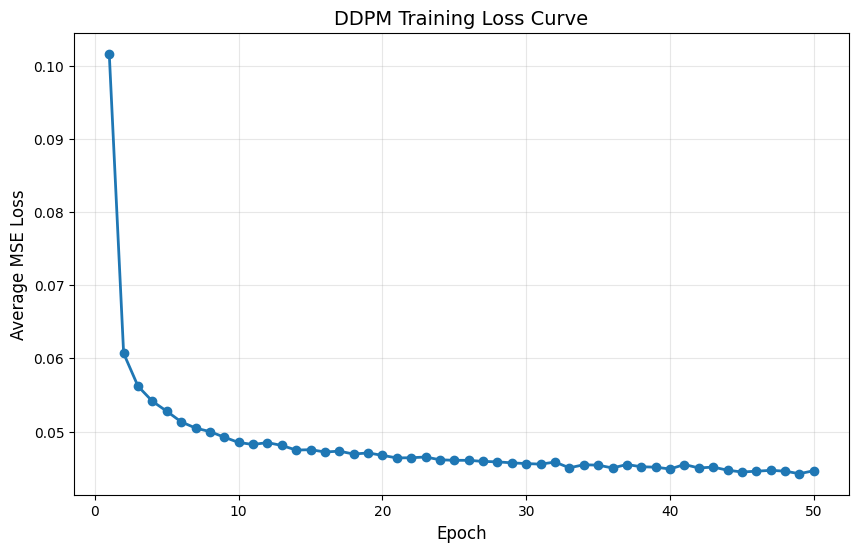

Loss曲線を保存: ddpm_training_curve.png

=== Training Statistics ===
Initial Loss (Epoch 1): 0.1016
Final Loss (Epoch 50): 0.0446
Best Loss: 0.0442 (Epoch 49)
Worst Loss: 0.1016 (Epoch 1)


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.utils import save_image
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt

# --- デバイス設定 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- モデル定義 (U-Net 簡易版) ---
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1),
            nn.ReLU(),
        )
        self.middle = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*2, 3, 1, 1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels*2, base_channels, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, out_channels, 3, 1, 1)
        )

    def forward(self, x, t_emb):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        return x

# --- βスケジュール (修正: 全てGPUへ) ---
T_steps = 1000
betas = torch.linspace(1e-4, 0.02, T_steps).to(device)
alphas = (1 - betas).to(device)
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

# --- ノイズ付与関数 ---
def q_sample(x_start, t, noise):
    sqrt_alphas_cumprod = alphas_cumprod[t] ** 0.5
    sqrt_one_minus_alphas_cumprod = (1 - alphas_cumprod[t]) ** 0.5
    return sqrt_alphas_cumprod[:, None, None, None] * x_start + \
           sqrt_one_minus_alphas_cumprod[:, None, None, None] * noise

# --- サンプル生成関数 ---
@torch.no_grad()
def sample_images(model, n_samples=8, size=64):
    """DDPMでランダムノイズから画像を生成"""
    model.eval()
    x = torch.randn(n_samples, 3, size, size).to(device)
    
    for t in reversed(range(T_steps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alphas_cumprod[t]
        
        if t > 0:
            z = torch.randn_like(x)
        else:
            z = 0
            
        x = (1 / alpha_t**0.5) * (
            x - (1 - alpha_t) / (1 - alpha_bar_t)**0.5 * eps_pred
        ) + beta_t**0.5 * z
    
    # [-1,1] -> [0,1]
    x = (x + 1) / 2.0
    x = torch.clamp(x, 0.0, 1.0)
    return x

# --- データ変換 ---
transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),  # [-1, 1] 正規化
])

# PCamデータセット流用
train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)

# --- 保存用ディレクトリ作成 ---
os.makedirs("ddpm_samples", exist_ok=True)
os.makedirs("ddpm_checkpoints", exist_ok=True)

# --- モデル初期化 ---
ddpm_model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(ddpm_model.parameters(), lr=1e-4)

# --- 学習ループ ---
epochs = 50
losses_history = []

print("=== DDPM Training Start ===")
print(f"Device: {device}")
print(f"Total epochs: {epochs}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Total batches per epoch: {len(train_loader)}")
print("="*50)

for epoch in range(epochs):
    ddpm_model.train()
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for x0, _ in pbar:
        x0 = x0.to(device)
        t = torch.randint(0, T_steps, (x0.size(0),), device=device)
        noise = torch.randn_like(x0)
        x_t = q_sample(x0, t, noise)
        noise_pred = ddpm_model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    
    # エポック平均Loss
    avg_loss = np.mean(epoch_losses)
    losses_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f}")
    
    # --- 10エポックごとにモデル保存 ---
    if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
        ckpt_path = f"ddpm_checkpoints/ddpm_pcam_epoch{epoch+1}.pth"
        torch.save(ddpm_model.state_dict(), ckpt_path)
        print(f"  → Saved checkpoint: {ckpt_path}")
    
    # --- 10エポックごとにサンプル生成 ---
    if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
        print(f"  → Generating samples...")
        samples = sample_images(ddpm_model, n_samples=16, size=64)
        sample_path = f"ddpm_samples/samples_epoch{epoch+1}.png"
        save_image(samples, sample_path, nrow=4)
        print(f"  → Saved samples: {sample_path}")

print("\n=== 学習完了! ===")

# --- Loss曲線のプロット ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), losses_history, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average MSE Loss', fontsize=12)
plt.title('DDPM Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('ddpm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss曲線を保存: ddpm_training_curve.png")

# --- 最終統計情報 ---
print("\n=== Training Statistics ===")
print(f"Initial Loss (Epoch 1): {losses_history[0]:.4f}")
print(f"Final Loss (Epoch {epochs}): {losses_history[-1]:.4f}")
print(f"Best Loss: {min(losses_history):.4f} (Epoch {losses_history.index(min(losses_history))+1})")
print(f"Worst Loss: {max(losses_history):.4f} (Epoch {losses_history.index(max(losses_history))+1})")